In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [9]:
df = pd.read_csv('imdb_top_1000_cleaned.xls')

In [10]:
df.head()

,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,No_of_Votes,Gross,Cast
0,The Shawshank Redemption,1994,A,142,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,2343110,28341469,"Tim Robbins, Morgan Freeman, Bob Gunton, Willi..."
1,The Godfather,1972,A,175,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,1620367,134966411,"Marlon Brando, Al Pacino, James Caan, Diane Ke..."
2,The Dark Knight,2008,UA,152,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,2303232,534858444,"Christian Bale, Heath Ledger, Aaron Eckhart, M..."
3,The Godfather: Part II,1974,A,202,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,1129952,57300000,"Al Pacino, Robert De Niro, Robert Duvall, Dian..."
4,12 Angry Men,1957,U,96,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,689845,4360000,"Henry Fonda, Lee J. Cobb, Martin Balsam, John ..."


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 713 entries, 0 to 712
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Series_Title   713 non-null    object 
 1   Released_Year  713 non-null    int64  
 2   Certificate    713 non-null    object 
 3   Runtime        713 non-null    int64  
 4   Genre          713 non-null    object 
 5   IMDB_Rating    713 non-null    float64
 6   Overview       713 non-null    object 
 7   Meta_score     713 non-null    float64
 8   Director       713 non-null    object 
 9   No_of_Votes    713 non-null    int64  
 10  Gross          713 non-null    int64  
 11  Cast           713 non-null    object 
dtypes: float64(2), int64(4), object(6)
memory usage: 67.0+ KB


In [12]:
df['Genre'].unique()

array(['Drama', 'Crime, Drama', 'Action, Crime, Drama',
       'Action, Adventure, Drama', 'Biography, Drama, History',
       'Action, Adventure, Sci-Fi', 'Drama, Romance', 'Western',
       'Action, Sci-Fi', 'Biography, Crime, Drama',
       'Action, Adventure, Fantasy', 'Comedy, Drama, Thriller',
       'Adventure, Drama, Sci-Fi', 'Animation, Adventure, Family',
       'Drama, War', 'Crime, Drama, Fantasy', 'Comedy, Drama, Romance',
       'Crime, Drama, Mystery', 'Crime, Drama, Thriller', 'Drama, Music',
       'Biography, Comedy, Drama', 'Drama, Mystery, Sci-Fi',
       'Biography, Drama, Music', 'Crime, Mystery, Thriller',
       'Animation, Adventure, Drama', 'Adventure, Comedy, Sci-Fi',
       'Horror, Mystery, Thriller', 'Drama, Romance, War',
       'Comedy, Drama, Family', 'Animation, Drama, Fantasy',
       'Animation, Action, Adventure', 'Drama, Western',
       'Action, Adventure', 'Comedy, Drama', 'Drama, Mystery, Thriller',
       'Action, Drama, Mystery', 'Mystery, Thr

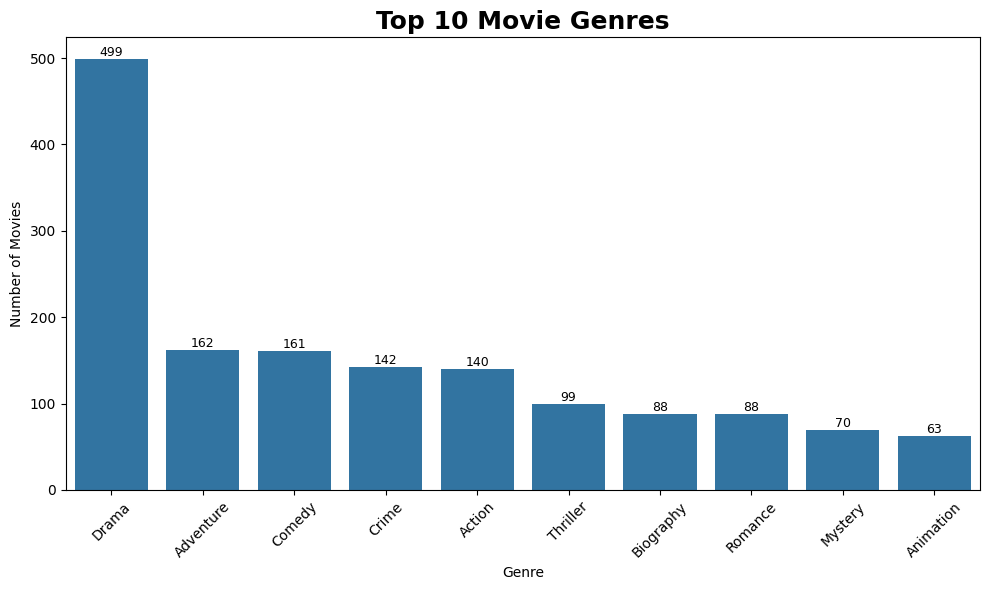

In [13]:
genre = (
    df['Genre']
      .str.split(', ')
      .explode()
)

top_genres = (
    genre.value_counts()
         .head(10)
         .reset_index()
)

top_genres.columns = ['Genre', 'Movie_Count']

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=top_genres,
    x='Genre',
    y='Movie_Count'
)

for container in ax.containers:
    ax.bar_label(container, fontsize=9)

plt.title(
    'Top 10 Movie Genres',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Genre')
plt.ylabel('Number of Movies')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

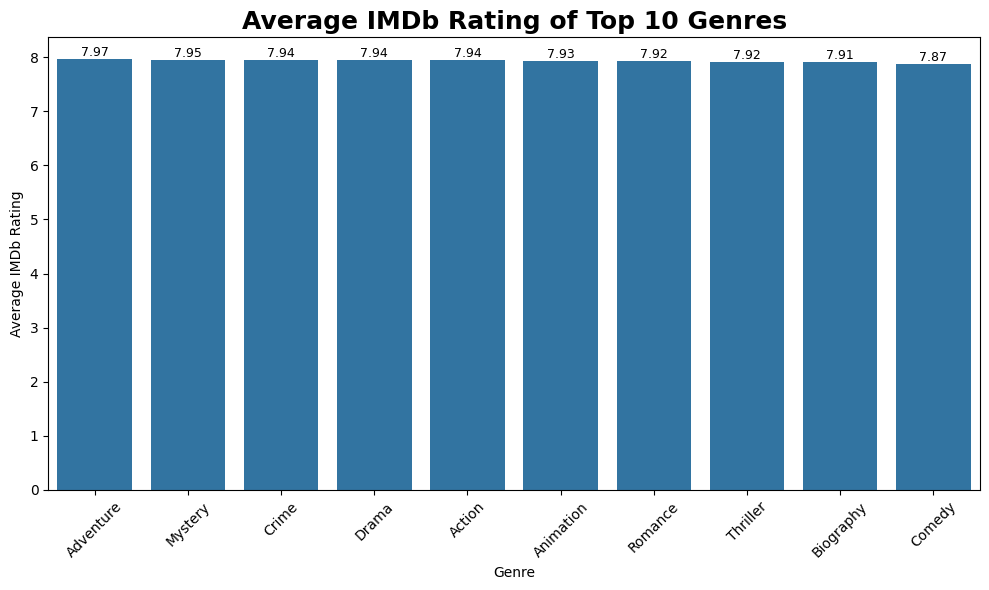

In [14]:
genre_rating = (
    df.assign(Genre=df['Genre'].str.split(', '))
      .explode('Genre')
)

genre_rating = (
    genre_rating.groupby('Genre')['IMDB_Rating']
                .mean()
                .reset_index()
)

genre_rating = (
    genre_rating[
        genre_rating['Genre'].isin(top_genres['Genre'])
    ].sort_values(
        by='IMDB_Rating',
        ascending=False
    )
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=genre_rating,
    x='Genre',
    y='IMDB_Rating'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9)

plt.title(
    'Average IMDb Rating of Top 10 Genres',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Genre')
plt.ylabel('Average IMDb Rating')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## 💡 Insight 1: Top Movie Genres vs IMDb Rating

The analysis shows that **Drama** is the most frequently produced genre in the dataset, with **499 movies**, making it the dominant genre in the film industry. Adventure and Comedy follow as the next most common genres, indicating that production companies consistently invest in these categories due to sustained audience demand.

Supporting analysis examined the **average IMDb ratings** of the top 10 genres. The results reveal that although **Drama** is the most popular genre by production volume, **Adventure** achieves the highest average IMDb rating (**7.97**). In addition, most of the top genres maintain similar average ratings between **7.87 and 7.97**, suggesting that audience appreciation remains consistently high across multiple genres.

These findings indicate that **producing more movies in a particular genre does not necessarily guarantee higher audience ratings**. For production companies, this suggests that investment decisions should balance **market demand (genre popularity)** with **audience satisfaction (IMDb ratings)** rather than relying solely on production volume.

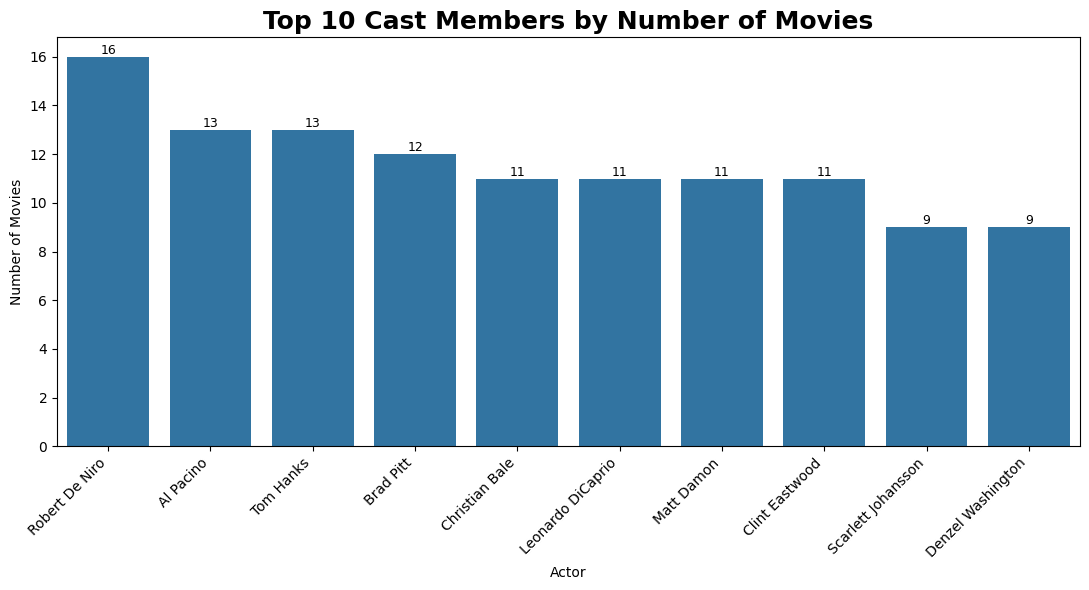

In [16]:
cast = (
    df['Cast']
      .str.split(', ')
      .explode()
)

top_cast = (
    cast.value_counts()
        .head(10)
        .reset_index()
)

top_cast.columns = ['Actor', 'Movie_Count']

plt.figure(figsize=(11,6))

ax = sns.barplot(
    data=top_cast,
    x='Actor',
    y='Movie_Count'
)

for container in ax.containers:
    ax.bar_label(container, fontsize=9)

plt.title(
    'Top 10 Cast Members by Number of Movies',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Actor')
plt.ylabel('Number of Movies')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()

plt.show()

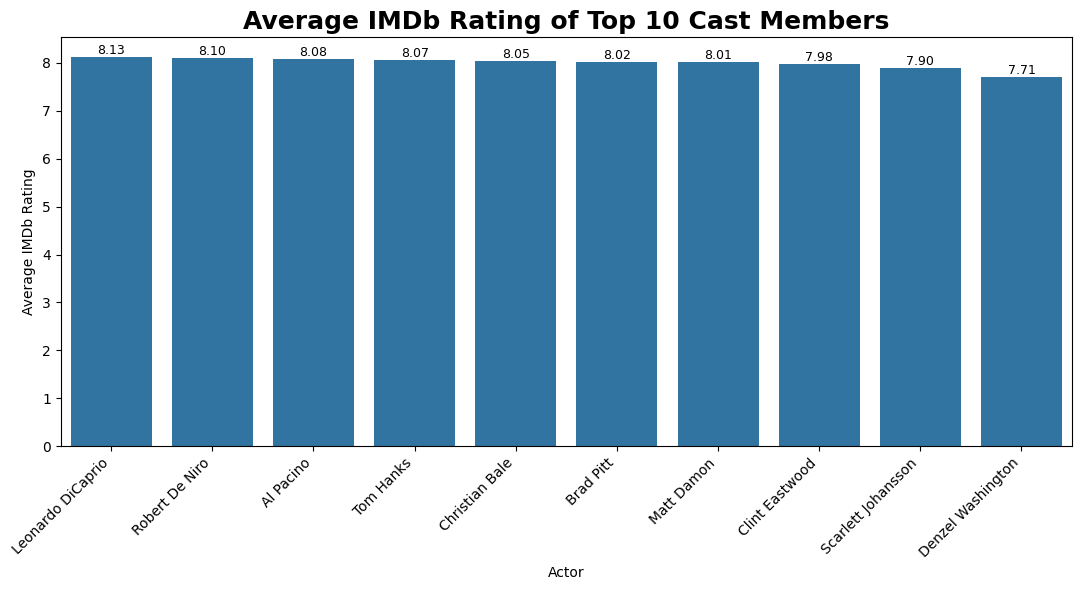

In [19]:
cast_rating = (
    df.assign(Cast=df['Cast'].str.split(', '))
      .explode('Cast')
)

cast_rating = (
    cast_rating.groupby('Cast')['IMDB_Rating']
               .mean()
               .reset_index(name='Average_IMDB_Rating')
)

cast_rating = (
    cast_rating[
        cast_rating['Cast'].isin(top_cast['Actor'])
    ]
    .sort_values(by='Average_IMDB_Rating', ascending=False)
)

plt.figure(figsize=(11,6))

ax = sns.barplot(
    data=cast_rating,
    x='Cast',
    y='Average_IMDB_Rating'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9)

plt.title(
    'Average IMDb Rating of Top 10 Cast Members',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Actor')
plt.ylabel('Average IMDb Rating')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()

plt.show()

## 💡 Insight 2: Top Cast Members vs Average IMDb Rating

The analysis identified the **top 10 cast members** based on the number of movies they appeared in. **Robert De Niro** leads the list with **16 movies**, followed by **Al Pacino** and **Tom Hanks**, highlighting their consistent presence in highly recognized films.

Supporting analysis examined the **average IMDb ratings** of these actors' movies. While **Leonardo DiCaprio** achieved the highest average IMDb rating (**8.13**), **Robert De Niro**, despite appearing in the most movies, maintained an impressive average rating of **8.10**. Most of the top actors recorded ratings above **8.0**, indicating that they consistently appear in critically acclaimed movies.

These findings suggest that **experienced and frequently cast actors tend to maintain high-quality film portfolios**. However, **appearing in a larger number of movies does not necessarily guarantee the highest audience ratings**, emphasizing that movie quality depends on multiple factors beyond the cast alone.

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 713 entries, 0 to 712
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Series_Title   713 non-null    object 
 1   Released_Year  713 non-null    int64  
 2   Certificate    713 non-null    object 
 3   Runtime        713 non-null    int64  
 4   Genre          713 non-null    object 
 5   IMDB_Rating    713 non-null    float64
 6   Overview       713 non-null    object 
 7   Meta_score     713 non-null    float64
 8   Director       713 non-null    object 
 9   No_of_Votes    713 non-null    int64  
 10  Gross          713 non-null    int64  
 11  Cast           713 non-null    object 
dtypes: float64(2), int64(4), object(6)
memory usage: 67.0+ KB


/tmp/ipykernel_1389/213560457.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Gross_Group')['IMDB_Rating']


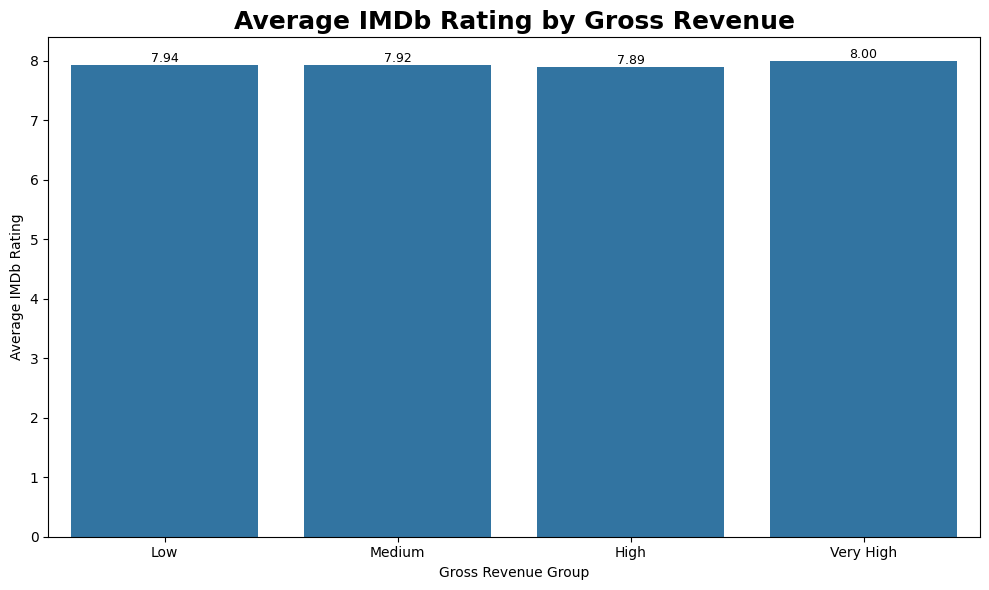

In [21]:
df['Gross_Group'] = pd.qcut(
    df['Gross'],
    q=4,
    labels=[
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

gross_rating = (
    df.groupby('Gross_Group')['IMDB_Rating']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=gross_rating,
    x='Gross_Group',
    y='IMDB_Rating'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9)

plt.title(
    'Average IMDb Rating by Gross Revenue',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Gross Revenue Group')
plt.ylabel('Average IMDb Rating')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1389/1205702918.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Gross_Group')['No_of_Votes']


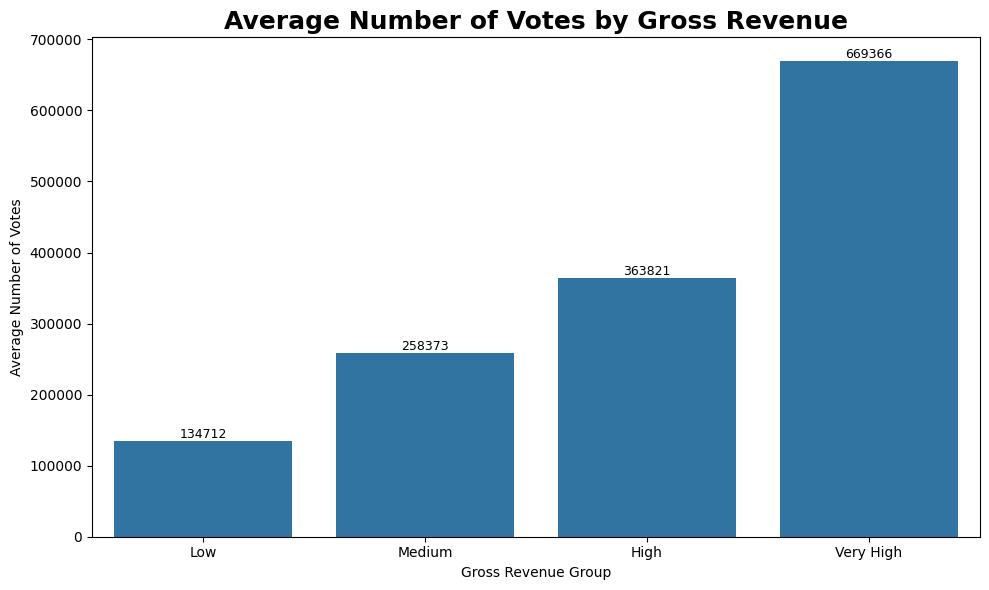

In [22]:
gross_votes = (
    df.groupby('Gross_Group')['No_of_Votes']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=gross_votes,
    x='Gross_Group',
    y='No_of_Votes'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=9)

plt.title(
    'Average Number of Votes by Gross Revenue',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Gross Revenue Group')
plt.ylabel('Average Number of Votes')

plt.tight_layout()
plt.show()

## 💡 Insight 3: Gross Revenue vs IMDb Rating

The analysis examined whether movies with higher box-office collections also achieve better audience ratings. The results show that **average IMDb ratings remain consistently high across all gross revenue groups**, ranging from **7.89 to 8.00**. Although the **Very High Gross** category records the highest average IMDb rating, the difference across revenue groups is relatively small.

Supporting analysis examined the **average number of audience votes** for each gross revenue group. A clear upward trend was observed, with movies in the **Very High Gross** category receiving nearly **669,000 average votes**, compared to only **135,000 votes** for low-grossing movies. This indicates that commercially successful movies attract significantly larger audiences and generate greater engagement on IMDb.

These findings suggest that **higher box-office revenue is driven more by audience reach and popularity than by substantially higher IMDb ratings**. For movie producers, this highlights that commercial success depends not only on producing high-quality films but also on maximizing audience exposure through effective marketing, distribution, and global reach.

In [23]:
df['Decade'] = (df['Released_Year'] // 10) * 10
df['Decade'] = df['Decade'].astype(str) + 's'

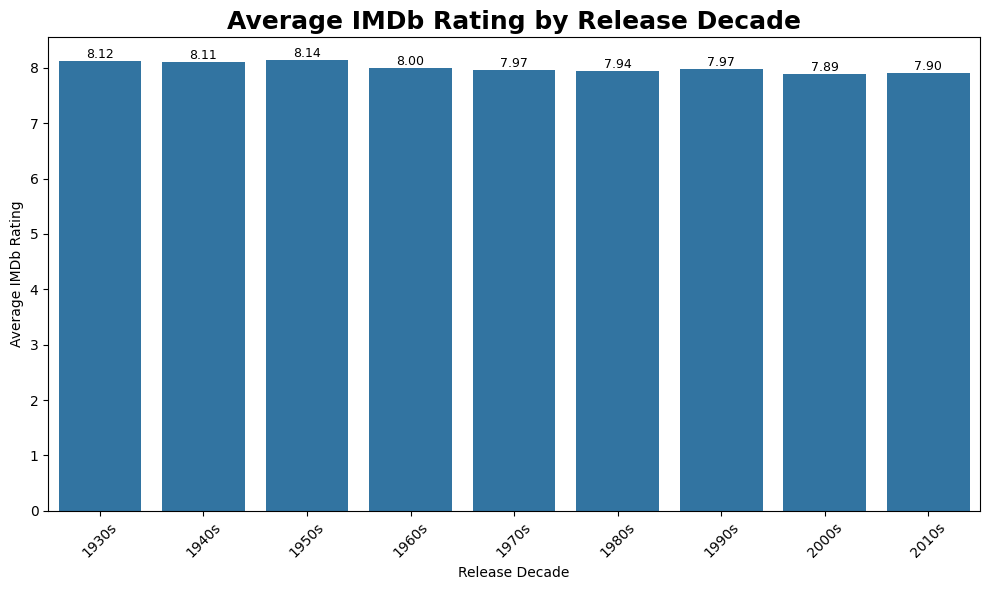

In [24]:
imdb_decade = (
    df.groupby('Decade')['IMDB_Rating']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=imdb_decade,
    x='Decade',
    y='IMDB_Rating'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9)

plt.title(
    'Average IMDb Rating by Release Decade',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Release Decade')
plt.ylabel('Average IMDb Rating')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

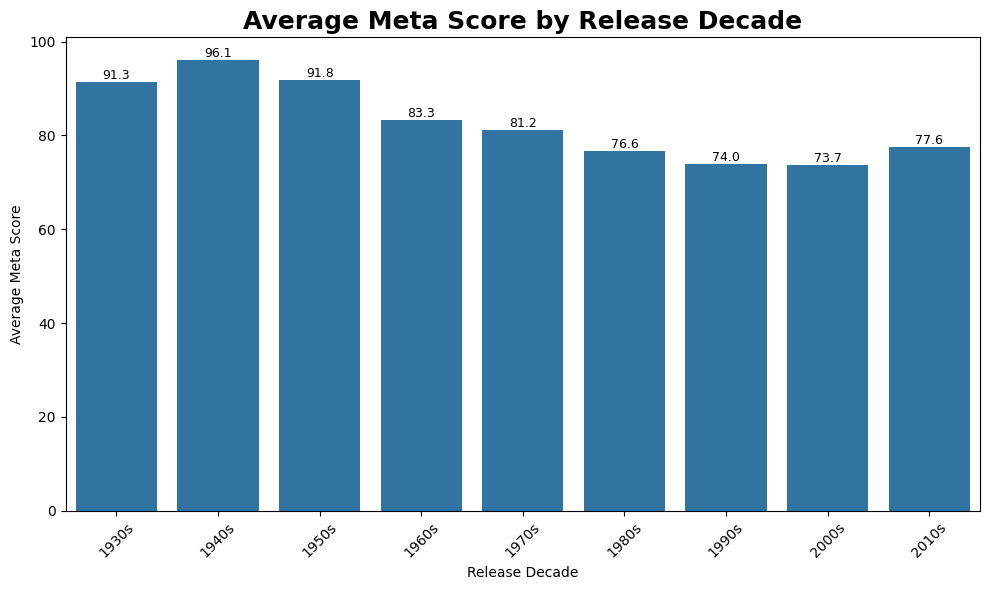

In [25]:
meta_decade = (
    df.groupby('Decade')['Meta_score']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=meta_decade,
    x='Decade',
    y='Meta_score'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=9)

plt.title(
    'Average Meta Score by Release Decade',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Release Decade')
plt.ylabel('Average Meta Score')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 💡 Insight 4: Release Decade vs IMDb Rating (Supported by Meta Score)

The analysis explored how movie quality has evolved over different release decades by examining both **IMDb ratings** (audience opinion) and **Meta Scores** (critic reviews). Movies released during the **1930s, 1940s, and 1950s** achieved the highest average IMDb ratings, all exceeding **8.10**, indicating that classic films continue to receive exceptional appreciation from audiences.

Supporting analysis using **Meta Scores** revealed a similar pattern. Movies from the **1940s** recorded the highest average Meta Score (**96.1**), while the **1930s** and **1950s** also received outstanding critic ratings above **91**. Although movies released in more recent decades continue to maintain strong IMDb ratings around **7.9–8.0**, their average Meta Scores are comparatively lower.

These findings suggest that **classic movies have stood the test of time**, earning consistently high appreciation from both audiences and professional critics. While modern films remain highly rated, the strongest agreement between audience satisfaction and critical acclaim is observed among movies released during the early decades.

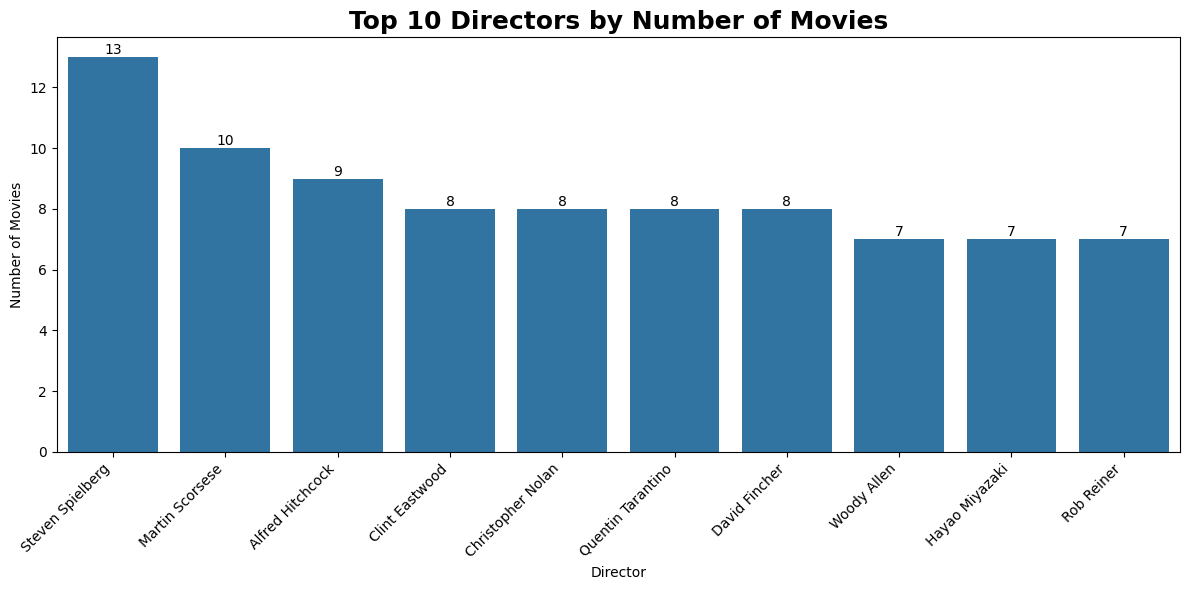

In [26]:
top_directors = (
    df['Director']
      .value_counts()
      .head(10)
      .reset_index()
)

top_directors.columns = ['Director', 'Movie_Count']

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_directors,
    x='Director',
    y='Movie_Count'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    'Top 10 Directors by Number of Movies',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Director')
plt.ylabel('Number of Movies')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

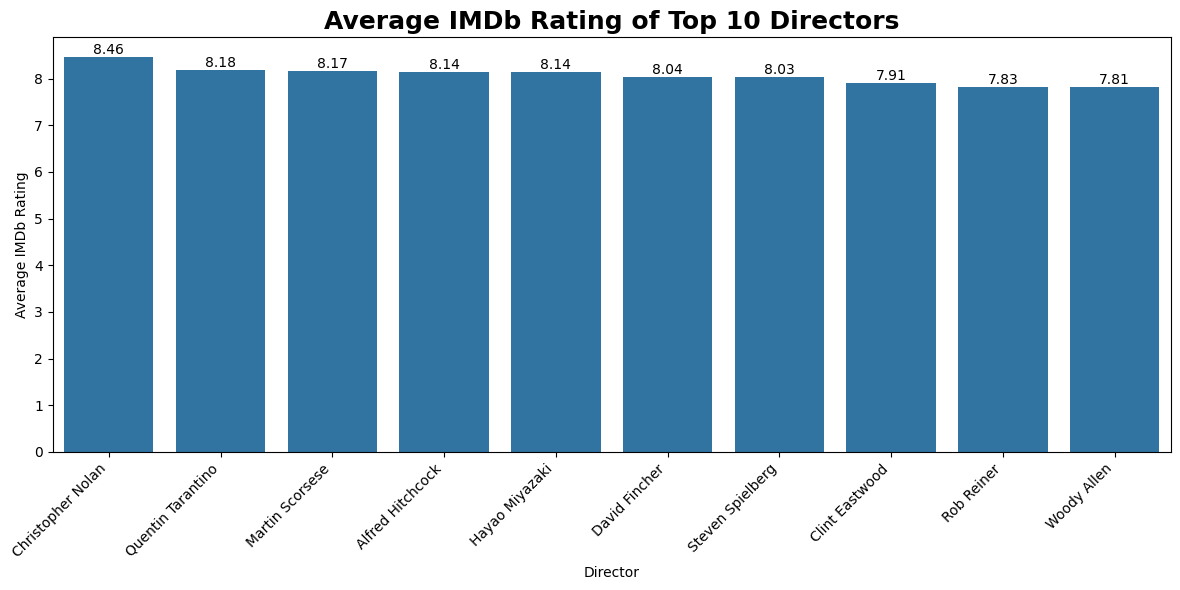

In [27]:
director_rating = (
    df.groupby('Director')['IMDB_Rating']
      .mean()
      .reset_index(name='Average_IMDB_Rating')
)

director_rating = (
    director_rating[
        director_rating['Director'].isin(top_directors['Director'])
    ]
    .sort_values(by='Average_IMDB_Rating', ascending=False)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=director_rating,
    x='Director',
    y='Average_IMDB_Rating'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.title(
    'Average IMDb Rating of Top 10 Directors',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Director')
plt.ylabel('Average IMDb Rating')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 💡 Insight 5: Top Directors by Number of Movies (Supported by IMDb Rating)

The analysis identified the **top 10 directors** based on the number of movies in the dataset. **Steven Spielberg** directed the highest number of movies (**13**), followed by **Martin Scorsese** (**10**) and **Alfred Hitchcock** (**9**). Their consistent presence reflects long and successful filmmaking careers.

Supporting analysis examined the **average IMDb ratings** of movies directed by these filmmakers. **Christopher Nolan** achieved the highest average IMDb rating (**8.46**), while **Quentin Tarantino**, **Martin Scorsese**, and **Alfred Hitchcock** also maintained ratings above **8.10**. Although Steven Spielberg directed the largest number of movies, his films still achieved an impressive average IMDb rating of **8.03**, highlighting consistent quality across a large portfolio.

These findings suggest that **experienced directors consistently deliver critically acclaimed movies over time**. While directing more movies does not necessarily result in the highest average rating, established filmmakers are more likely to build strong and reliable filmographies, making them valuable choices for production studios seeking both quality and consistency.

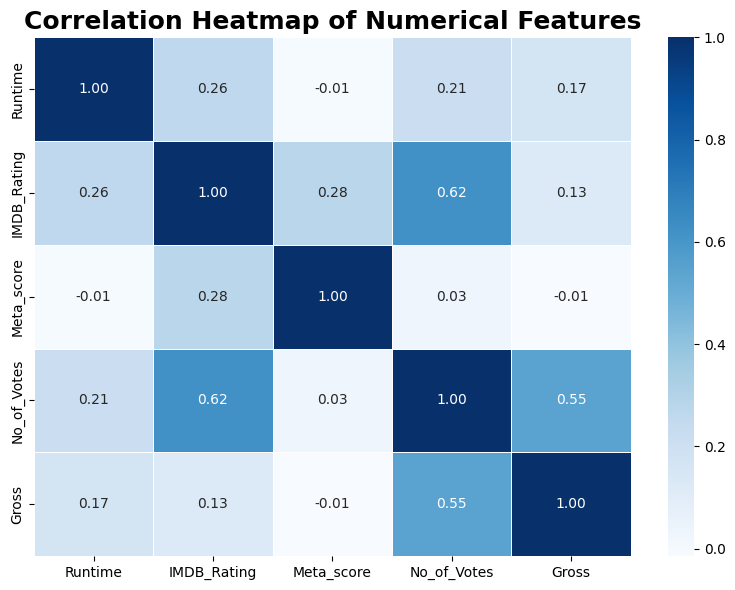

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = [
    'Runtime',
    'IMDB_Rating',
    'Meta_score',
    'No_of_Votes',
    'Gross'
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='Blues',
    fmt='.2f',
    linewidths=0.5
)

plt.title(
    'Correlation Heatmap of Numerical Features',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## 📊 Correlation Heatmap

The correlation heatmap summarizes the relationships among the key numerical variables in the IMDb Movies dataset. The strongest positive relationship is observed between **Gross Revenue** and **Number of Votes**, indicating that movies with greater audience engagement generally achieve higher box-office collections. **IMDb Rating** and **Meta Score** also exhibit a positive correlation, suggesting that audience opinions and critic reviews often align for highly regarded movies. Runtime shows only a weak relationship with ratings and revenue, indicating that movie length alone does not determine commercial or critical success. Overall, audience popularity and movie quality emerge as the strongest indicators of financial performance.

# 📌 Conclusion

This Exploratory Data Analysis provided valuable insights into the factors that contribute to a movie's popularity, quality, and commercial success. The analysis revealed that **Drama** dominates the dataset in terms of movie count while consistently maintaining high IMDb ratings. Frequently appearing actors and experienced directors continue to deliver critically acclaimed films, demonstrating the importance of strong filmmaking experience.

The study also showed that movies generating higher box-office revenue attract significantly larger audiences, reflected by a substantial increase in the number of IMDb votes. However, higher gross revenue does not necessarily guarantee dramatically better audience ratings, indicating that commercial success depends on both movie quality and audience reach.

Analysis across release decades revealed that classic movies continue to receive exceptional appreciation from both audiences and critics, highlighting the timeless appeal of well-crafted storytelling. Overall, the correlation analysis confirmed that audience engagement, measured through the number of votes, has the strongest relationship with commercial success, while critic reviews and audience ratings generally move in the same direction.

These insights can help production houses, streaming platforms, and movie distributors make informed decisions regarding genre selection, director collaborations, marketing strategies, and long-term investment in film projects.